# README

To execute this notebook correctly, you must first download and extract the experimental dataset available on Zenodo in the base folder. The dataset archive contains:

* an annotation.json file,
* and an images/ folder containing the cropped text-line images used for the analysis.

The figure below summarizes the structure of the dataset and the different components used throughout the analysis pipeline.

* The dataset consists of cropped text-line images associated with an annotation.json file containing:
    * the transcription labels of each image,
    * and a set of metadata fields describing the document context (see Figure below).
    
* The granularity and nature of the metadata depend on the research question and level of analysis. In this study, the metadata include fields such as:
    * "folio",
    * "zone type",
    * "line type",
    * and "graphic profile".
* The unit of analysis in this dataset is the page.
* The input/ directory contains the raw outputs generated from the dataset using the DTLR for paleography architecture. It includes:
    * one folder per page containing the extracted prototypes per page and per character,
    * and a character_measurement/ folder containing one .json file per text line with character-level bounding-box measurements and associated metrics (see Figure below).
    ![diagram](./media/explanation_dataset_components.png)

# Applying the Analysis to Your Own Data

This pipeline is designed to work both for the original analysis (Raoulet/Henri manuscript with Graphic Profiles, recto/verso columns, etc.) **and for any other DTLR-derived dataset**. The defaults reproduce the paper's figures; override them in `StudyConfig` and `build_and_crop_working_corpus()` to adapt to your data.

### Required input structure
Whatever your dataset, you need:
* an `annotation.json` mapping each line image filename to a metadata dict,
* a `character_measurements/` folder with one sub-directory per document and   one `.json` per transcribed line (DTLR output),
* (optional) `text_line_images/` if you want cropped bbox images,
* (optional) `prototypes/` and `transcribe.json` for the prototype-overlay plots.

### Annotation fields used by the pipeline
The pipeline reads these fields from `annotation.json` *if they exist*:

| Field   | Used for                                                                 |
|---------|--------------------------------------------------------------------------|
| `line`  | Line-type filter (`line_type_filter` in `StudyConfig`)                   |
| `zone`  | Column/zone filter (`zone_mode`, `line_selection_mode`)                  |
| `gp`    | Default grouping field — colour-codes points in plots (`group_field`)    |
| `folio` | Page label and natural sort order on the x-axis                          |

**None of these are mandatory.** The three knobs that adapt the pipeline:

1. **`group_field`** (default `"gp"`) — annotation field used to colour-group    documents. Set to a different field (e.g. `"script"`, `"scribe"`) or `None`    to disable grouping.
2. **`doc_key_parts`** (default `2`) — how many `_`-separated parts of a line    filename form the document key.
3. **`line_type_filter`** (default `"DefaultLine"`) — value of the `line` field    to keep. Set to `None` if your data has no `line` field.

### Two independent character lists at corpus-build time
* **`target_characters`** — what stays in the in-memory corpus and is available   for metric computation.
* **`crop_characters`** — what gets saved as bbox PNGs to disk (only matters when   `crop_images=True`). These are independent: you can compute metrics on every   character but only crop bboxes for `['t', 'd', 'n']`.

### Friendly metric names with `m()`
Plot functions accept raw column names (`"mean_b_distance_m_en"`) but for readability the helper `m()` builds them from a friendly description:

```python
m("letter", "n", "AR")                       # -> "mean_ar_n"
m("bigram", "en", "normalized distance")     # -> "mean_b_distance_m_en"
m("word",   "normalized distance")            # -> "mean_w_distance_normalized_m"
```

Pass an unknown metric name to see the list of accepted aliases for that kind.


# Imports

In [3]:
import os
import re
import json
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict

from PIL import Image
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize

import matplotlib.pyplot as plt
from matplotlib import colors, cm

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.lines import Line2D

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

plt.rcParams['text.usetex'] = True

import sys
sys.path.append(str(Path("scripts")))

from metrics_viz import (StudyConfig, FolioIndex, m, compute_letter_metrics, compute_bigram_metrics, 
                                 compute_word_metrics, plot_linear, plot_cross)
from build_corpus import (build_doc_mappings, build_line_mappings, build_character_index_map, 
                        build_and_crop_working_corpus, compute_working_corpus_statistics)

# File Paths

In [4]:
from pathlib import Path

# start from current working directory
current = Path().resolve()

# walk upward until we find a marker of the repo root
for parent in [current] + list(current.parents):
    if (parent / "input").exists() and (parent / "dataset").exists():
        base_dir = parent
        break
else:
    raise FileNotFoundError("Could not locate project root (input/ and dataset/ missing)")

In [5]:
# --- Subpaths ---
#inputs
prototypes                  = base_dir / "input/prototypes"
character_mapping           = base_dir / "input/transcribe.json"
character_measurements      = base_dir / "input/character_measurements"

#dataset
annotation_json             = base_dir / "dataset/annotation.json"
text_line_images            = base_dir / "dataset/images"

#save results
fig_output_dir              = base_dir / "results/figures"
cropped_character_bboxes    = base_dir / "results/cropped_character_bboxes"

## Here we define constants for visualisations via a config. We define filters for the working corpus construction, as well as character and bigram markers, highlighting folios etc that we use for the analysis.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Define ONE config — used by build_and_crop_working_corpus, FolioIndex,
# the metric functions, and the plot functions. No duplication anywhere.
#
# Defaults below reproduce the paper analysis. Adjust the "Generalisation"
# block to adapt to other datasets.
# ─────────────────────────────────────────────────────────────────────────────
config = StudyConfig(
    annotation_json        = annotation_json,
    character_measurements = character_measurements,
    fig_output_dir         = fig_output_dir,
    prototypes             = prototypes,

    # ── Generalisation: change these to adapt to your dataset ────────────────
    group_field            = "gp",           # None | "script" | "scribe" | ...
    doc_key_parts          =  2,               # parts of the filename forming the doc key
    line_type_filter       = "DefaultLine",   # None to keep all lines
    line_selection_mode    = "recto_verso",   # None | "MainZone#1" | "MainZone#2" | "recto_verso"

    # ── BBox outlier filter ──────────────────────────────────────────────────
    bbox_filter_mode       = "threshold",
    outlier_std_threshold  = 4.0,

    # ── Gathering ranges shown in every linear plot — change only if needed ──
    highlight_ranges = [
        ('1r',   '7v'),
        ('170r', '178r'), ('178r', '185v'),
        ('401r', '409r'), ('409r', '416v'),
        ('467r', '474v'), ('474v', '480v'),
    ],
    gathering_labels = {
        ('1r',   '7v'):   "Gath. I",
        ('170r', '178r'): "Gath. XXII",
        ('178r', '185v'): "Gath. XXIII",
        ('401r', '409r'): "Gath. LII",
        ('409r', '416v'): "Gath. LIII",
        ('467r', '474v'): "Gath. LXII",
        ('474v', '480v'): "Gath. LXIII",
    },

    # ── Markers (sensible defaults; override only if needed) ─────────────────
    letter_markers = {'a': 's', 't': 'x', 'd': '*', 'e': 'P', 'n': 'o'},
    bigram_markers = {'en': 'o', 'de': 'p', 'le': '^'},
)

idx = FolioIndex(config)
print(f"Corpus has {len(idx.all_folios_sorted)} total folios/pages")
print(f"Resolved group colours: {idx.group_colors}")


Corpus has 164 total folios/pages
Resolved group colours: {'GP1': '#009E73', 'GP2': '#E69F00', 'GP3': '#0072B2', 'GP4': '#CC79A7'}


# Build dataset metadata  mappings (map characters to their image index, Graphic Profiles per page, lines to zone number (left or right column))

In [9]:
# ── Mappings (built once, reused everywhere) ──────────────────────────────
character_sprite_map = build_character_index_map(character_mapping)
doc_mappings,  _     = build_doc_mappings(annotation_json)
line_mappings, _     = build_line_mappings(annotation_json)

## Build the working corpus

`build_and_crop_working_corpus` reads the dataset-structure parameters (`group_field`, `doc_key_parts`, `line_type_filter`, `line_selection_mode`, `bbox_filter_mode`, `outlier_std_threshold`) directly from the `config` object defined above — no duplication. Pass any of these as keyword arguments only if you want to override the config for this specific call.

* When `crop_images=True`, bbox crops are saved separately for kept and   discarded instances according to the configured filtering criteria.
* The `group_label` argument of `compute_working_corpus_statistics` controls   the column header in the summary table — `"GP"` for the original analysis,   `"Script"` / `"Document"` / etc. for other groupings.


In [10]:
corpus, stats, metadata_rows = build_and_crop_working_corpus(
    character_measurements   = character_measurements,
    text_line_images         = text_line_images,
    cropped_character_bboxes = cropped_character_bboxes,
    annotation_json          = annotation_json,
    config                   = config,                # single source of truth
    target_characters        = None,                  # None = all characters
    character_sprite_map     = character_sprite_map,
    crop_images              = False,                 # True saves kept/discarded bbox PNGs
)

df_gp, df_char = compute_working_corpus_statistics(
    corpus, stats, group_label="script"      # change to "Script"/"Document"/... for other groupings
)


Processing corpus: 100%|██████████████████| 6015/6015 [00:00<00:00, 6872.45it/s]


WORKING CORPUS — SCRIPT SUMMARY



,script,Docs,Folios,Lines,Total predictions,Match predictions,% discarded (no match),Final characters
0,GP1,65,65,2981,125662,124086,1.25,124086
1,GP2,54,54,2178,84437,83332,1.31,83332
2,GP3,35,35,1354,57348,56656,1.21,56656
3,GP4,6,6,291,12227,12077,1.23,12077



WORKING CORPUS — CHARACTER SUMMARY



,Character,Count
0,,47429
1,.,3233
2,:,20
3,A,73
4,B,56
...,...,...
71,Ꝙ,1
72,ꝙ,25
73,ꝯ,238
74,ꝰ,47


# From the available measurements provided by the bounding boxes of the corpus, we define metrics for computing the width, height, aspect ratio of a character as well as disatnce between characters and words (graphic units separated by a space). For the definitions of the computer metrics refer to the "compute_character_metrics" "compute_bigram_metrics" "compute_word_metrics" in metrics_viz.py. Metrics are computed per page (our unit of analysis).

## From all of the available measurements in the dataset, we create a df with the metrics for the letters/bigrams of interest as well as word separation

## See the dataframe and the  for the name per metric: *mean_ar_{character}* for example is the AR of "a" and *mean_b_distance_m_{bigram}* is the bigram distance normalized by half the average (per page) width of the lowercase m. On the definition of measures, see paper section 3.3 "Measures". 

![diagram](./media/measures_definition.jpeg)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  Compute metrics (Accumulate into one wide DataFrame)
# ─────────────────────────────────────────────────────────────────────────────
df = idx.base_df()

# letters
for char in ["n", "a", "t", "d", "e"]:
    df = compute_letter_metrics(df, corpus, char, config)

# bigrams (case-sensitive: "de" matches only lowercase d+e, "De" only D+e, etc.)
for bigram in ["en", "de", "le"]:
    df = compute_bigram_metrics(df, bigram, config, idx)

# word
df = compute_word_metrics(df, config, idx)

# Sanity check using the m() helper for readability
ar_n = m("letter", "n", "AR")           # -> "mean_ar_n"
missing = df[df[ar_n].isna()]["folio"].tolist()
print(f"Pages with no data for {ar_n}: {missing}")
print(f"{df[ar_n].notna().sum()} units in the working corpus")
print(df.shape)
df.head()


Pages with no data for mean_ar_n: ['2r', '353vb', '473v', '484ra']
160 units in the working corpus
(164, 51)


,folder,folio,gp,mean_ar_n,std_ar_n,cv_ar_n,count_n,mean_ar_a,std_ar_a,cv_ar_a,...,mean_distance,std_distance,cv_distance,mean_w_distance_normalized_m,std_distance_normalized_m,cv_distance_normalized_m,mean_distance_normalized_avg,std_distance_normalized_avg,cv_distance_normalized_avg,n_word_distances
0,btv1b84472995_f009,1r,GP1,1.060171,0.046619,0.043973,93.0,1.000912,0.052786,0.052738,...,7.971703,5.613236,0.704145,0.272656,0.191989,0.704145,0.235881,0.166094,0.704145,312.0
1,btv1b84472995_f010,1v,GP1,1.067496,0.044567,0.041749,95.0,1.016031,0.044624,0.043920,...,10.212872,8.329806,0.815618,0.343840,0.280442,0.815618,0.295765,0.241231,0.815618,309.0
2,btv1b84472995_f011,2r,GP1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,btv1b84472995_f015,4r,GP1,1.096236,0.032932,0.030041,12.0,1.087084,0.025708,0.023649,...,10.135592,5.476542,0.540328,0.326623,0.176483,0.540328,0.280484,0.151553,0.540328,30.0
4,btv1b84472995_f016,4v,GP1,1.046178,0.045502,0.043493,124.0,1.024704,0.050292,0.049079,...,9.689374,6.883575,0.710425,0.324995,0.230885,0.710425,0.282933,0.201003,0.710425,348.0


# Visualisations

![diagram](./media/dummy_graphs.jpeg)

See also the examples below.

## Linear plots. We plot the figures in the paper section 4.3, Figures 6 and 7. 

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:1228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: linear_mean_ar_a_mean_ar_n_mean_ar_t_mean_ar_d_mean_ar_e_recto_verso.jpeg


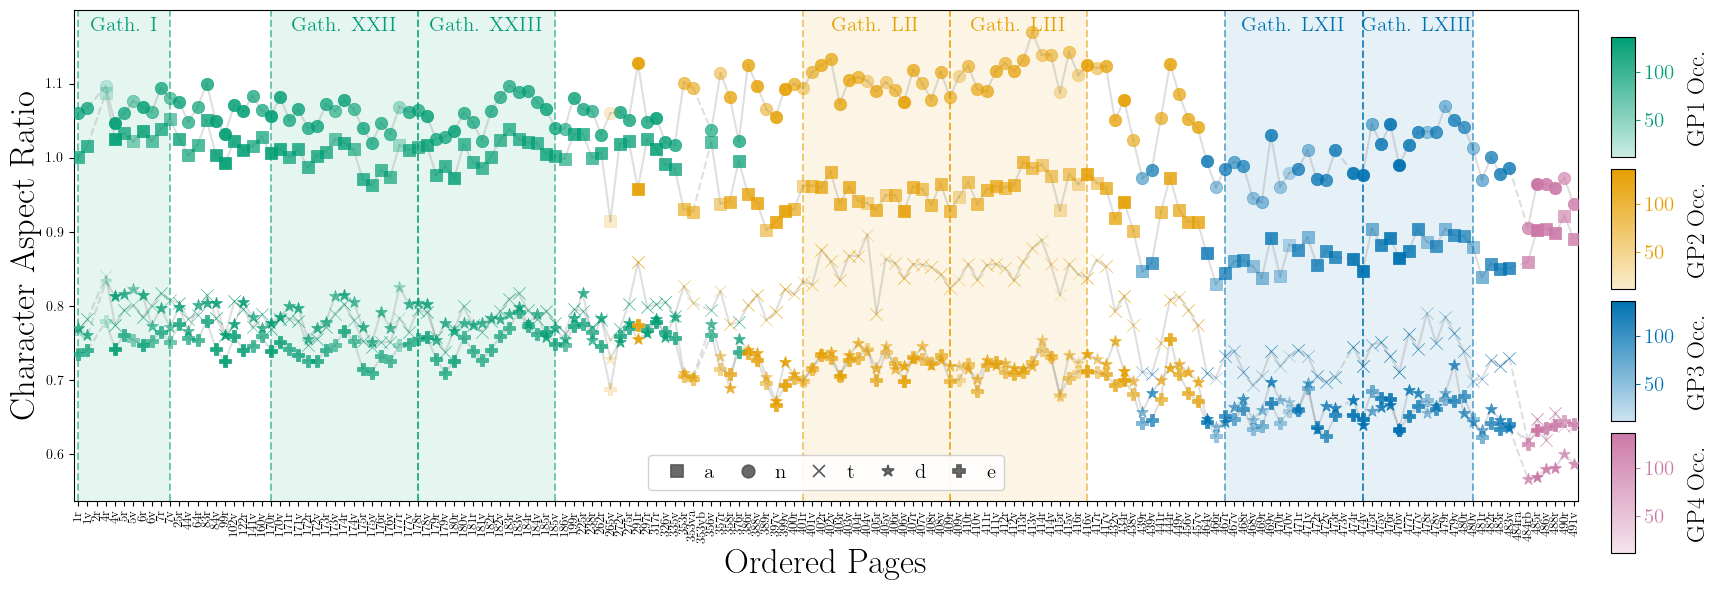

In [12]:
# ── LINEAR PLOTS ─────────────────────────────────────────────────────────────
# Letter AR: a, n, t, d, e
plot_linear(
    df,
    y_metric=[m("letter", c, "AR") for c in ["a", "n", "t", "d", "e"]],
    config=config, idx=idx,
    y_label_override="Character Aspect Ratio",
)

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:1228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: linear_mean_b_distance_m_en_mean_b_distance_m_de_mean_b_distance_m_le_recto_verso.jpeg


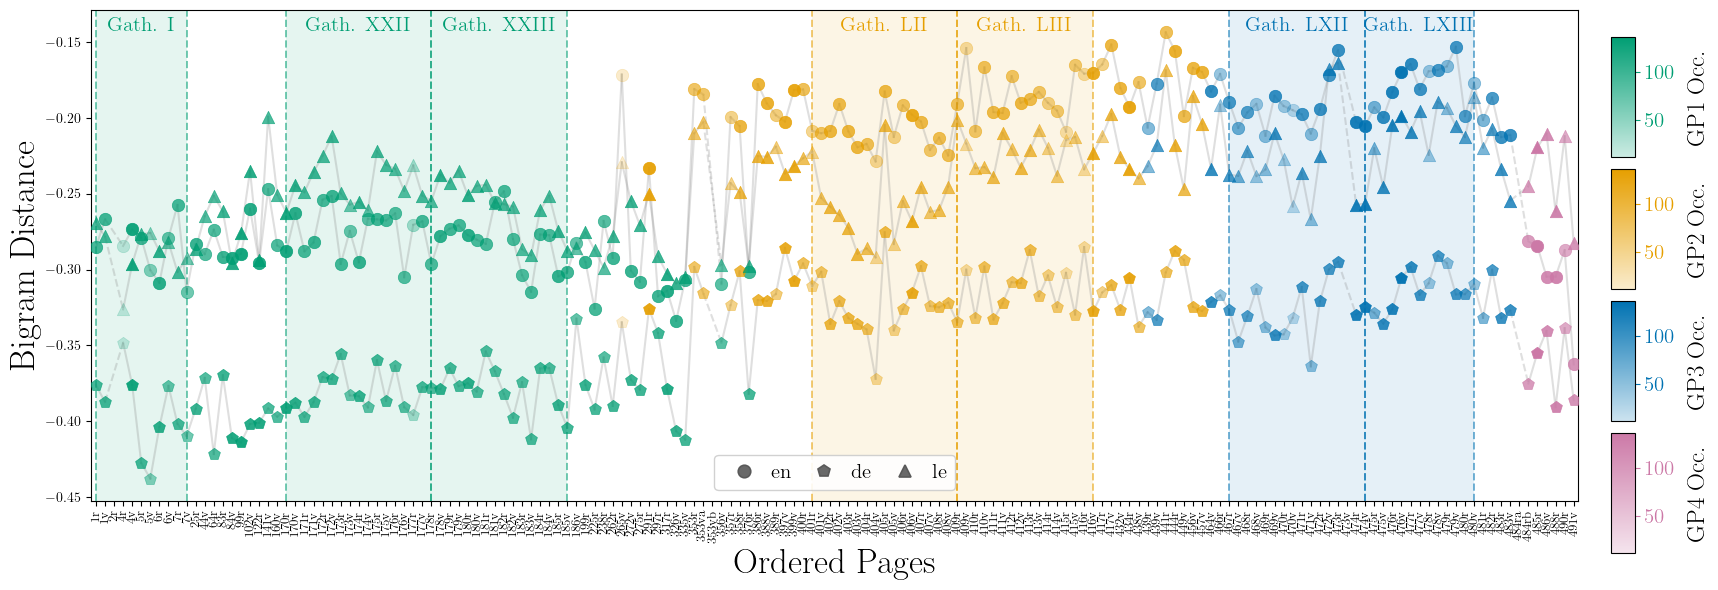

In [14]:
# Bigram edge-to-edge distance: en, de, le
plot_linear(
    df,
    y_metric=[m("bigram", b, "normalized distance") for b in ["en", "de", "le"]],
    config=config, idx=idx,
    y_label_override="Bigram Distance",
)

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:1228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: linear_mean_w_distance_normalized_m_recto_verso.jpeg


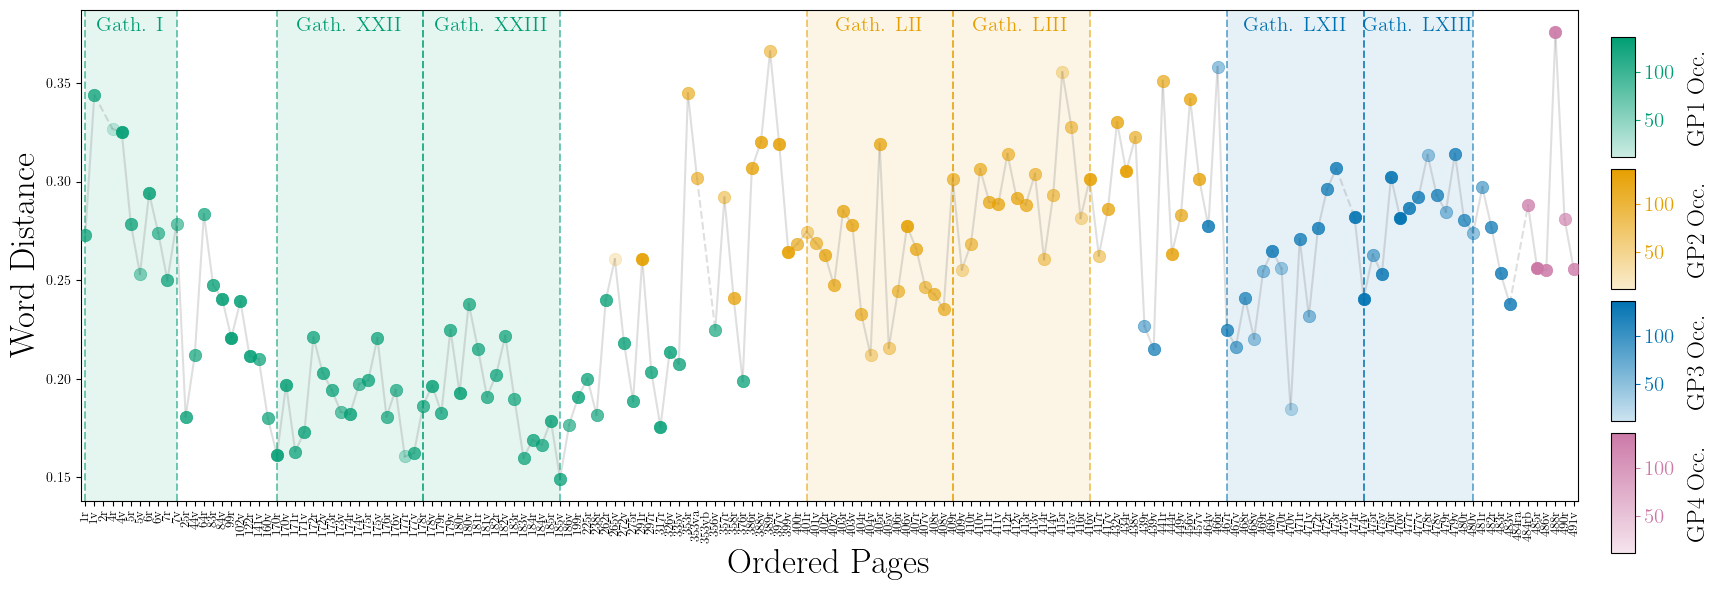

In [15]:
# Word separation
plot_linear(
    df,
    y_metric=m("word", "normalized distance"),
    config=config, idx=idx,
)

## Crossed plots

/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:1378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: cross_mean_ar_n_vs_mean_ar_a_recto_verso.jpeg


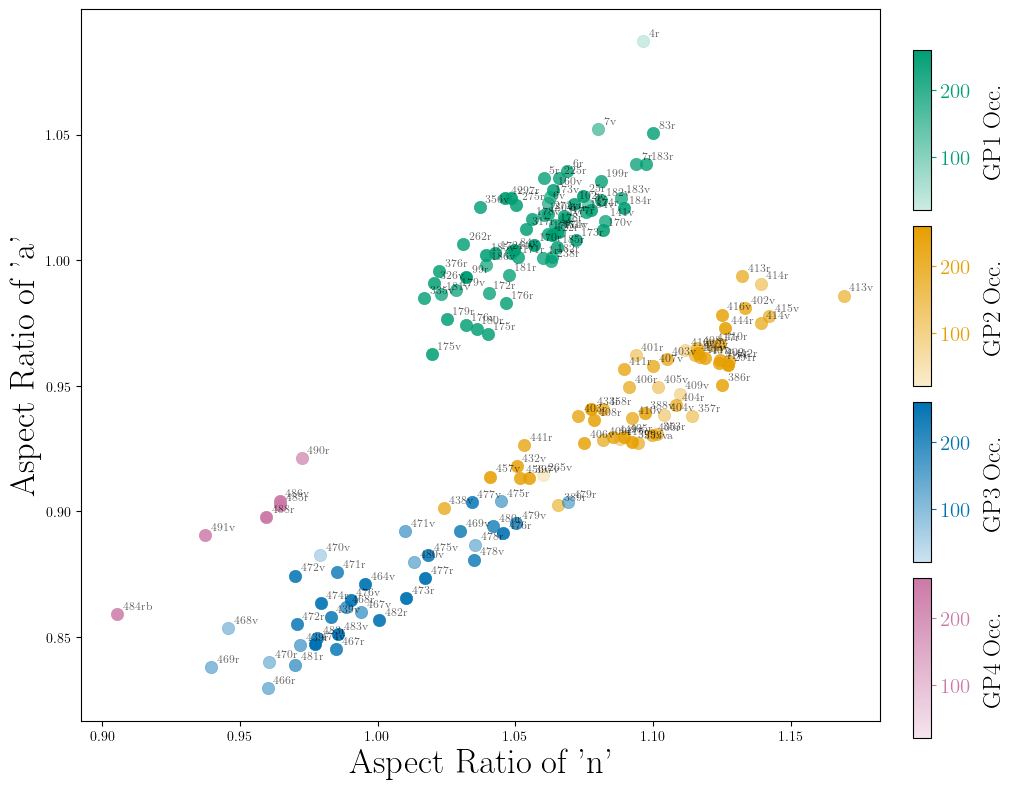

In [16]:
# AR of n vs AR of a
plot_cross(
    df,
    x_metric=m("letter", "n", "AR"),
    y_metric=m("letter", "a", "AR"),
    config=config, idx=idx,
)


/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:1378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: cross_mean_ar_t_vs_cv_ar_t_recto_verso.jpeg


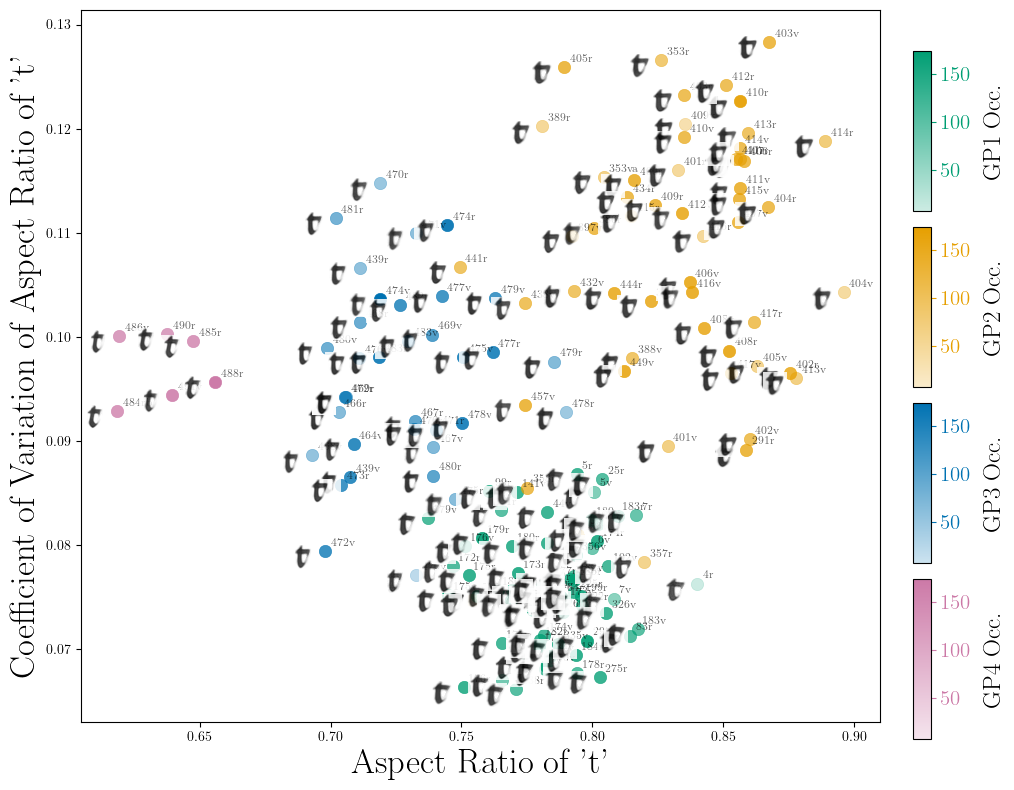

In [17]:
# AR of t vs CV of t — with prototype overlay
plot_cross(
    df,
    x_metric=m("letter", "t", "AR"),
    y_metric=m("letter", "t", "AR CV"),
    config=config, idx=idx,
    overlay_prototypes=True, proto_char="t",
    character_sprite_map=character_sprite_map,
)


/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:1378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: cross_mean_b_distance_m_en_vs_mean_b_ar_en_recto_verso.jpeg


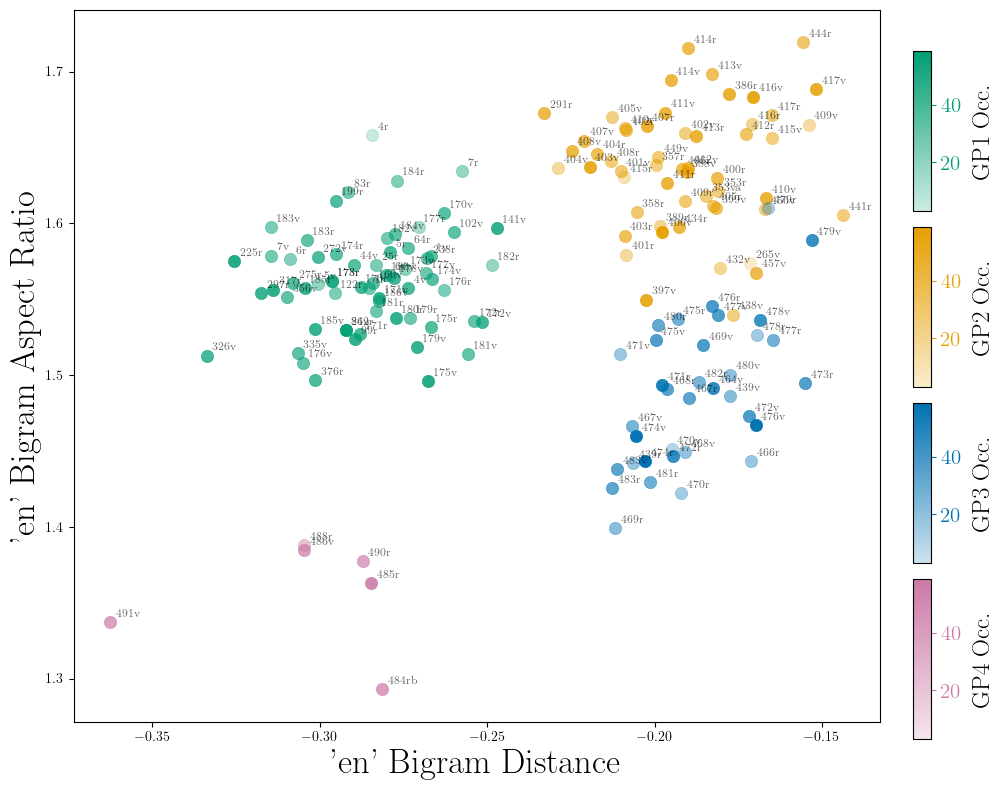

In [19]:
# Edge-to-edge distance of "en" vs AR of "en"
plot_cross(
    df,
    x_metric=m("bigram", "en", "normalized distance"),
    y_metric=m("bigram", "en", "AR"),
    config=config, idx=idx,
)


/Users/vlachou/Desktop/uni/IRHT-EPHE-ENPC/CIPL/expes/Raoulet_Henri/ICDAR2026/DTLR_ICDAR/dtlr-for-metrology/scripts/metrics_viz.py:1378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: cross_mean_b_distance_m_de_vs_cv_b_distance_de_recto_verso.jpeg


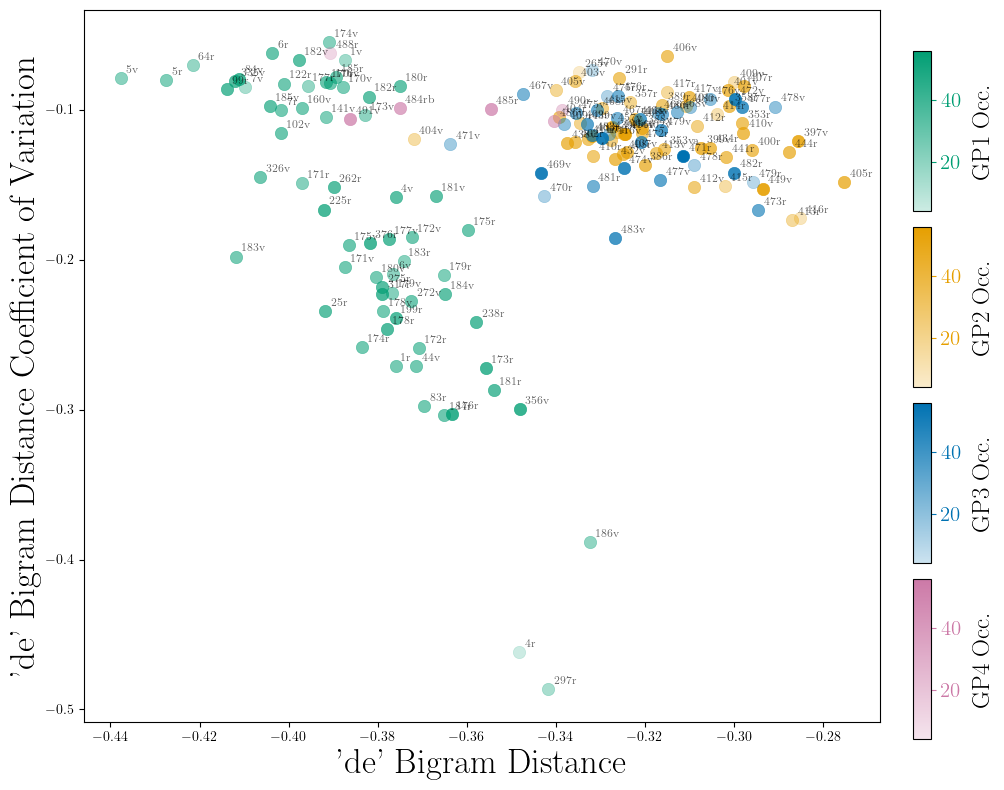

In [20]:
# Edge-to-edge distance of "de" vs CV of distance of "de"
plot_cross(
    df,
    x_metric=m("bigram", "de", "normalized distance"),
    y_metric=m("bigram", "de", "distance CV"),
    config=config, idx=idx,
)